# Setup

In [1]:
# standard library imports
import time

# third party library imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

# machine learning imports
from catboost import CatBoostRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    make_scorer,
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
    root_mean_squared_log_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    TargetEncoder,
)
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# local imports
from utils import (
    adversarial_score,
    barplot,
    countplot,
    heatmap,
    histplot,
    kdeplot,
    lineplot,
    scatterplot,
    subplots,
)

In [2]:
# patch sklearn for performance boost
from sklearnex import patch_sklearn

patch_sklearn(verbose=False)

# EDA

In [3]:
# load data
index_col = "id"
train_data = pd.read_csv("train.csv", index_col=index_col)
test_data = pd.read_csv("test.csv", index_col=index_col)
sub_data = pd.read_csv("sample_submission.csv", index_col=index_col)

In [4]:
# preview data
train_data

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500
...,...,...,...,...,...,...,...,...,...,...,...,...
188528,Cadillac,Escalade ESV Platinum,2017,49000,Gasoline,420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Beige,None reported,Yes,27500
188529,Mercedes-Benz,AMG C 43 AMG C 43 4MATIC,2018,28600,Gasoline,385.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,30000
188530,Mercedes-Benz,AMG GLC 63 Base 4MATIC,2021,13650,Gasoline,469.0HP 4.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes,86900


In [5]:
# check data types
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   brand         188533 non-null  str  
 1   model         188533 non-null  str  
 2   model_year    188533 non-null  int64
 3   milage        188533 non-null  int64
 4   fuel_type     183450 non-null  str  
 5   engine        188533 non-null  str  
 6   transmission  188533 non-null  str  
 7   ext_col       188533 non-null  str  
 8   int_col       188533 non-null  str  
 9   accident      186081 non-null  str  
 10  clean_title   167114 non-null  str  
 11  price         188533 non-null  int64
dtypes: int64(3), str(9)
memory usage: 17.3 MB


In [6]:
# check for missing values in each column
train_data.isna().sum().sort_values(ascending=False)

clean_title     21419
fuel_type        5083
accident         2452
brand               0
milage              0
model_year          0
model               0
engine              0
ext_col             0
transmission        0
int_col             0
price               0
dtype: int64

In [7]:
# check for unique values
train_data.nunique()

brand             57
model           1897
model_year        34
milage          6651
fuel_type          7
engine          1117
transmission      52
ext_col          319
int_col          156
accident           2
clean_title        1
price           1569
dtype: int64

In [8]:
# process data
import re  # noqa: E40

main_int_colors = [
    "Beige",
    "Black",
    "Blue",
    "Brown",
    "Gold",
    "Green",
    "Grey",
    "Orange",
    "Red",
    "Silver",
    "White",
    "Yellow",
]

main_ext_colors = [
    "Beige",
    "Black",
    "Blue",
    "Brown",
    "Gold",
    "Green",
    "Grey",
    "Orange",
    "Purple",
    "Red",
    "Silver",
    "White",
    "Yellow",
]

int_color_replacements = {
    "Camel": "Beige",
    "Camel Leather": "Beige",
    "Chateau": "Beige",
    "Gideon": "Beige",
    "Linen": "Beige",
    "Macchiato": "Beige",
    "Medium Light Camel": "Beige",
    "Oyster W/Contrast": "Beige",
    "Oyster/Black": "Beige",
    "Parchment": "Beige",
    "Parchment.": "Beige",
    "Sahara Tan": "Beige",
    "Sandstone": "Beige",
    "Tan": "Beige",
    "Tan/Ebony": "Beige",
    "Tan/Ebony/Ebony": "Beige",
    "Very Light Cashmere": "Beige",
    "Beluga": "Black",
    "Beluga Hide": "Black",
    "Blk": "Black",
    "Ebony": "Black",
    "Ebony.": "Black",
    "Ebony / Ebony Accents": "Black",
    "Ebony / Pimento": "Black",
    "Ebony/Light Oyster Stitch": "Black",
    "Nero": "Black",
    "Nero Ade": "Black",
    "Navy Pier": "Blue",
    "Boulder": "Brown",
    "Brandy": "Brown",
    "Cappuccino": "Brown",
    "Caramel": "Brown",
    "Chestnut": "Brown",
    "Cocoa / Dune": "Brown",
    "Dark Auburn": "Brown",
    "Deep Chestnut": "Brown",
    "Espresso": "Brown",
    "Mesa": "Brown",
    "Mocha": "Brown",
    "Roast": "Brown",
    "Tupelo": "Brown",
    "Walnut": "Brown",
    "Giallo Taurus / Nero Ade": "Gold",
    "Deep Cypress": "Green",
    "Anthracite": "Grey",
    "Ash": "Grey",
    "Charcoal": "Grey",
    "Dark Ash": "Grey",
    "Dark Galvanized": "Grey",
    "Diesel Gray / Black": "Grey",
    "Graphite": "Grey",
    "Graphite w/Gun Metal": "Grey",
    "Gray w/Blue Bolsters": "Grey",
    "Light Slate": "Grey",
    "Medium Dark Slate": "Grey",
    "Medium Pewter": "Grey",
    "Medium Stone": "Grey",
    "Portland": "Grey",
    "Porpoise": "Grey",
    "Shale": "Grey",
    "Slate": "Grey",
    "Tension": "Grey",
    "Amber": "Orange",
    "Sakhir Orange/Black": "Orange",
    "Deep Garnet": "Red",
    "Hotspur": "Red",
    "Hotspur Hide": "Red",
    "Orchid": "Red",
    "Pimento / Ebony": "Red",
    "Light Titanium": "Silver",
    "Platinum": "Silver",
    "–": "Unknown",
    "Sport": "Unknown",
    "Bianco Polar": "White",
    "Ceramic": "White",
    "Cloud": "White",
    "Ice": "White",
    "Ivory / Ebony": "White",
    "White / Brown": "White",
}

ext_color_replacements = {
    "Sandstone Metallic": "Beige",
    "Tan": "Beige",
    "Caviar": "Black",
    "Ebony Twilight Metallic": "Black",
    "Manhattan Noir Metallic": "Black",
    "Nero Daytona": "Black",
    "Nero Noctis": "Black",
    "Obsidian": "Black",
    "Onyx": "Black",
    "BLU ELEOS": "Blue",
    "Blu": "Blue",
    "Dark Sapphire": "Blue",
    "Mountain Air Metallic": "Blue",
    "Nightfall Mica": "Blue",
    "Stormy Sea": "Blue",
    "Tempest": "Blue",
    "Bronze": "Brown",
    "Bronze Dune Metallic": "Brown",
    "Burnished Bronze Metallic": "Brown",
    "Black Forest Green": "Green",
    "Dark Moss": "Green",
    "Gecko Pearlcoat": "Green",
    "Verde": "Green",
    "Dark Ash Metallic": "Grey",
    "Dark Graphite Metallic": "Grey",
    "Dark Matter Metallic": "Grey",
    "Dark Slate Metallic": "Grey",
    "Daytona Gray Pearl Effect w/ Black Roof": "Grey",
    "Designo Magno Matte": "Grey",
    "Granite": "Grey",
    "Granite Crystal Clearcoat Metallic": "Grey",
    "Granite Crystal Metallic Clearcoat": "Grey",
    "Grigio Nimbus": "Grey",
    "Gun Metallic": "Grey",
    "Iridium Metallic": "Grey",
    "Lunar Rock": "Grey",
    "Magnetic Metallic": "Grey",
    "Rift Metallic": "Grey",
    "Tungsten Metallic": "Grey",
    "Arancio Borealis": "Orange",
    "Ember Pearlcoat": "Orange",
    "Go Mango!": "Orange",
    "Mango Tango Pearlcoat": "Orange",
    "Sunset Drift Chromaflair": "Orange",
    "Ametrin Metallic": "Purple",
    "Majestic Plum Metallic": "Purple",
    "Pink": "Purple",
    "Black Cherry": "Red",
    "Maroon": "Red",
    "Rich Garnet Metallic": "Red",
    "Rosso": "Red",
    "Rosso Corsa": "Red",
    "Rosso Mars Metallic": "Red",
    "Ruby Flare Pearl": "Red",
    "Scarlet Ember": "Red",
    "Billet Clearcoat Metallic": "Silver",
    "Liquid Platinum": "Silver",
    "Maximum Steel Metallic": "Silver",
    "Metallic": "Silver",
    "Platinum Quartz Metallic": "Silver",
    "Satin Steel Metallic": "Silver",
    "–": "Unknown",
    "C / C": "Unknown",
    "Custom Color": "Unknown",
    "Bianco Icarus Metallic": "White",
    "Bianco Isis": "White",
    "Bianco Monocerus": "White",
    "Chalk": "White",
    "Glacier": "White",
    "Ice": "White",
    "Iridescent Pearl Tricoat": "White",
    "Moonlight Cloud": "White",
    "Wind Chill Pearl": "White",
    "Yulong": "White",
    "Hellayella Clearcoat": "Yellow",
}


def assign_cylinders(engine: str):
    s = str(engine).lower()
    match = re.search(r"(\d+)\s*cylinders?", s)
    if match:
        return float(match.group(1))
    match = re.search(r"\b[iv](\d+)\b", s)
    if match:
        return float(match.group(1))
    return None


def assign_displacement(engine: str):
    s = str(engine).lower()
    match = re.search(r"(\d+\.?\d*)\s*l(?:iter)?", s)
    if match:
        return float(match.group(1))
    return None


def assign_fuel_type(fuel_type):
    return {
        "–": "Unknown",
        "E85 Flex Fuel": "Gasoline",
        "not supported": "Unknown",
        np.nan: "Unknown",
        "Plug-In Hybrid": "Hybrid",
    }.get(fuel_type, fuel_type)


def assign_horsepower(engine: str):
    s = str(engine).lower()
    match = re.search(r"(\d+\.?\d*)\s*hp", s)
    if match:
        return float(match.group(1))
    return None


def assign_main_int_color(int_col: str):
    if int_col in int_color_replacements:
        return int_color_replacements[int_col]
    int_col = int_col.replace("Gray", "Grey")
    return next(c for c in main_int_colors if c.lower() in int_col.lower())


def assign_main_ext_color(ext_col: str):
    if ext_col in ext_color_replacements:
        return ext_color_replacements[ext_col]
    ext_col = ext_col.replace("Gray", "Grey")
    return next(c for c in main_ext_colors if c.lower() in ext_col.lower())


def assign_transmission(transmission: str):
    s = str(transmission).lower()
    if re.search(r"cvt|variable", s):
        return "CVT"
    if re.search(r"dct|dual.?shift", s):
        return "DCT"
    if re.search(r"\bm/?t\b|manual|speed mt", s):
        return "MT"
    if re.search(r"\ba/?t\b|automatic|auto|speed at", s):
        return "AT"
    return "Unknown"


def assign_transmission_speed(transmission: str):
    s = str(transmission).lower()
    if re.search(r"single-speed", s):
        return 1
    match = re.search(r"^(\d+)-speed", s)
    if match:
        return int(match.group(1))
    return None


def assign_turbo(engine: str):
    s = str(engine).lower()
    if re.search(r"twin turbo", s):
        return 2
    if re.search(r"turbo", s):
        return 1
    return 0


def process_data(df: pd.DataFrame):
    new_df = df.copy()

    if "price" in new_df.columns:
        new_df["price"] = new_df["price"].clip(upper=500_000)

    new_df["accident"] = new_df["accident"].fillna("None reported")
    new_df["clean_title"] = new_df["clean_title"].fillna("No")

    new_df["cylinders"] = new_df["engine"].map(assign_cylinders)
    new_df["displacement"] = new_df["engine"].map(assign_displacement)
    new_df["ext_col"] = new_df["ext_col"].map(assign_main_ext_color)
    new_df["fuel_type"] = new_df["fuel_type"].map(assign_fuel_type)
    new_df["horsepower"] = new_df["engine"].map(assign_horsepower)
    new_df["int_col"] = new_df["int_col"].map(assign_main_int_color)
    new_df["transmission_speed"] = new_df["transmission"].map(assign_transmission_speed)
    new_df["transmission"] = new_df["transmission"].map(assign_transmission)
    new_df["turbo"] = new_df["engine"].map(assign_turbo)

    return new_df.drop(columns="engine")


train_data = process_data(train_data)
test_data = process_data(test_data)

count    188533.000
mean      42390.286
std       48695.355
min        2000.000
25%       17000.000
50%       30825.000
75%       49900.000
max      500000.000
Name: price, dtype: float64

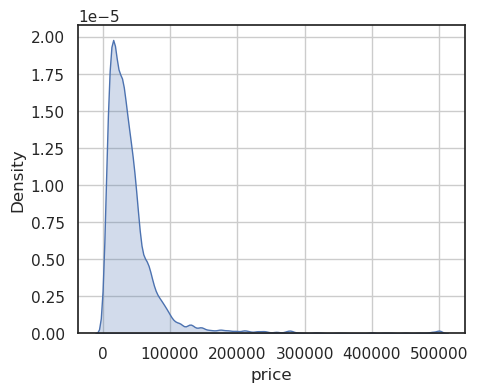

In [9]:
# set target
target = "price"
ax = kdeplot(x=train_data[target])
train_data[target].describe()

In [10]:
# set features
numerical_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "milage",
    "model_year",
    "transmission_speed",
]
ordinal_features = [
    "accident",
    "clean_title",
    "turbo",
]
ordinal_categories = [
    ["None reported", "At least 1 accident or damage reported"],  # accident
    ["No", "Yes"],  # clean_title
    [0, 1, 2],  # turbo
]
nominal_features = [
    "ext_col",
    "fuel_type",
    "int_col",
    "transmission",
]
high_cardinality_features = [
    "brand",
    "model",
]

categorical_features = nominal_features + ordinal_features + high_cardinality_features
features = numerical_features + categorical_features

plot_features = sorted(numerical_features + categorical_features)
corr_features = [target] + sorted(
    numerical_features + ordinal_features + high_cardinality_features
)

In [11]:
# use copies for exploratory analysis
train_data_encoded = train_data.copy()
test_data_encoded = test_data.copy()

# encode categorical features
feature_encoders = {}
for feature in categorical_features:
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1).fit(
        train_data[[feature]]
    )
    train_data_encoded[[feature]] = encoder.transform(train_data[[feature]])
    test_data_encoded[[feature]] = encoder.transform(test_data[[feature]])
    feature_encoders[feature] = encoder

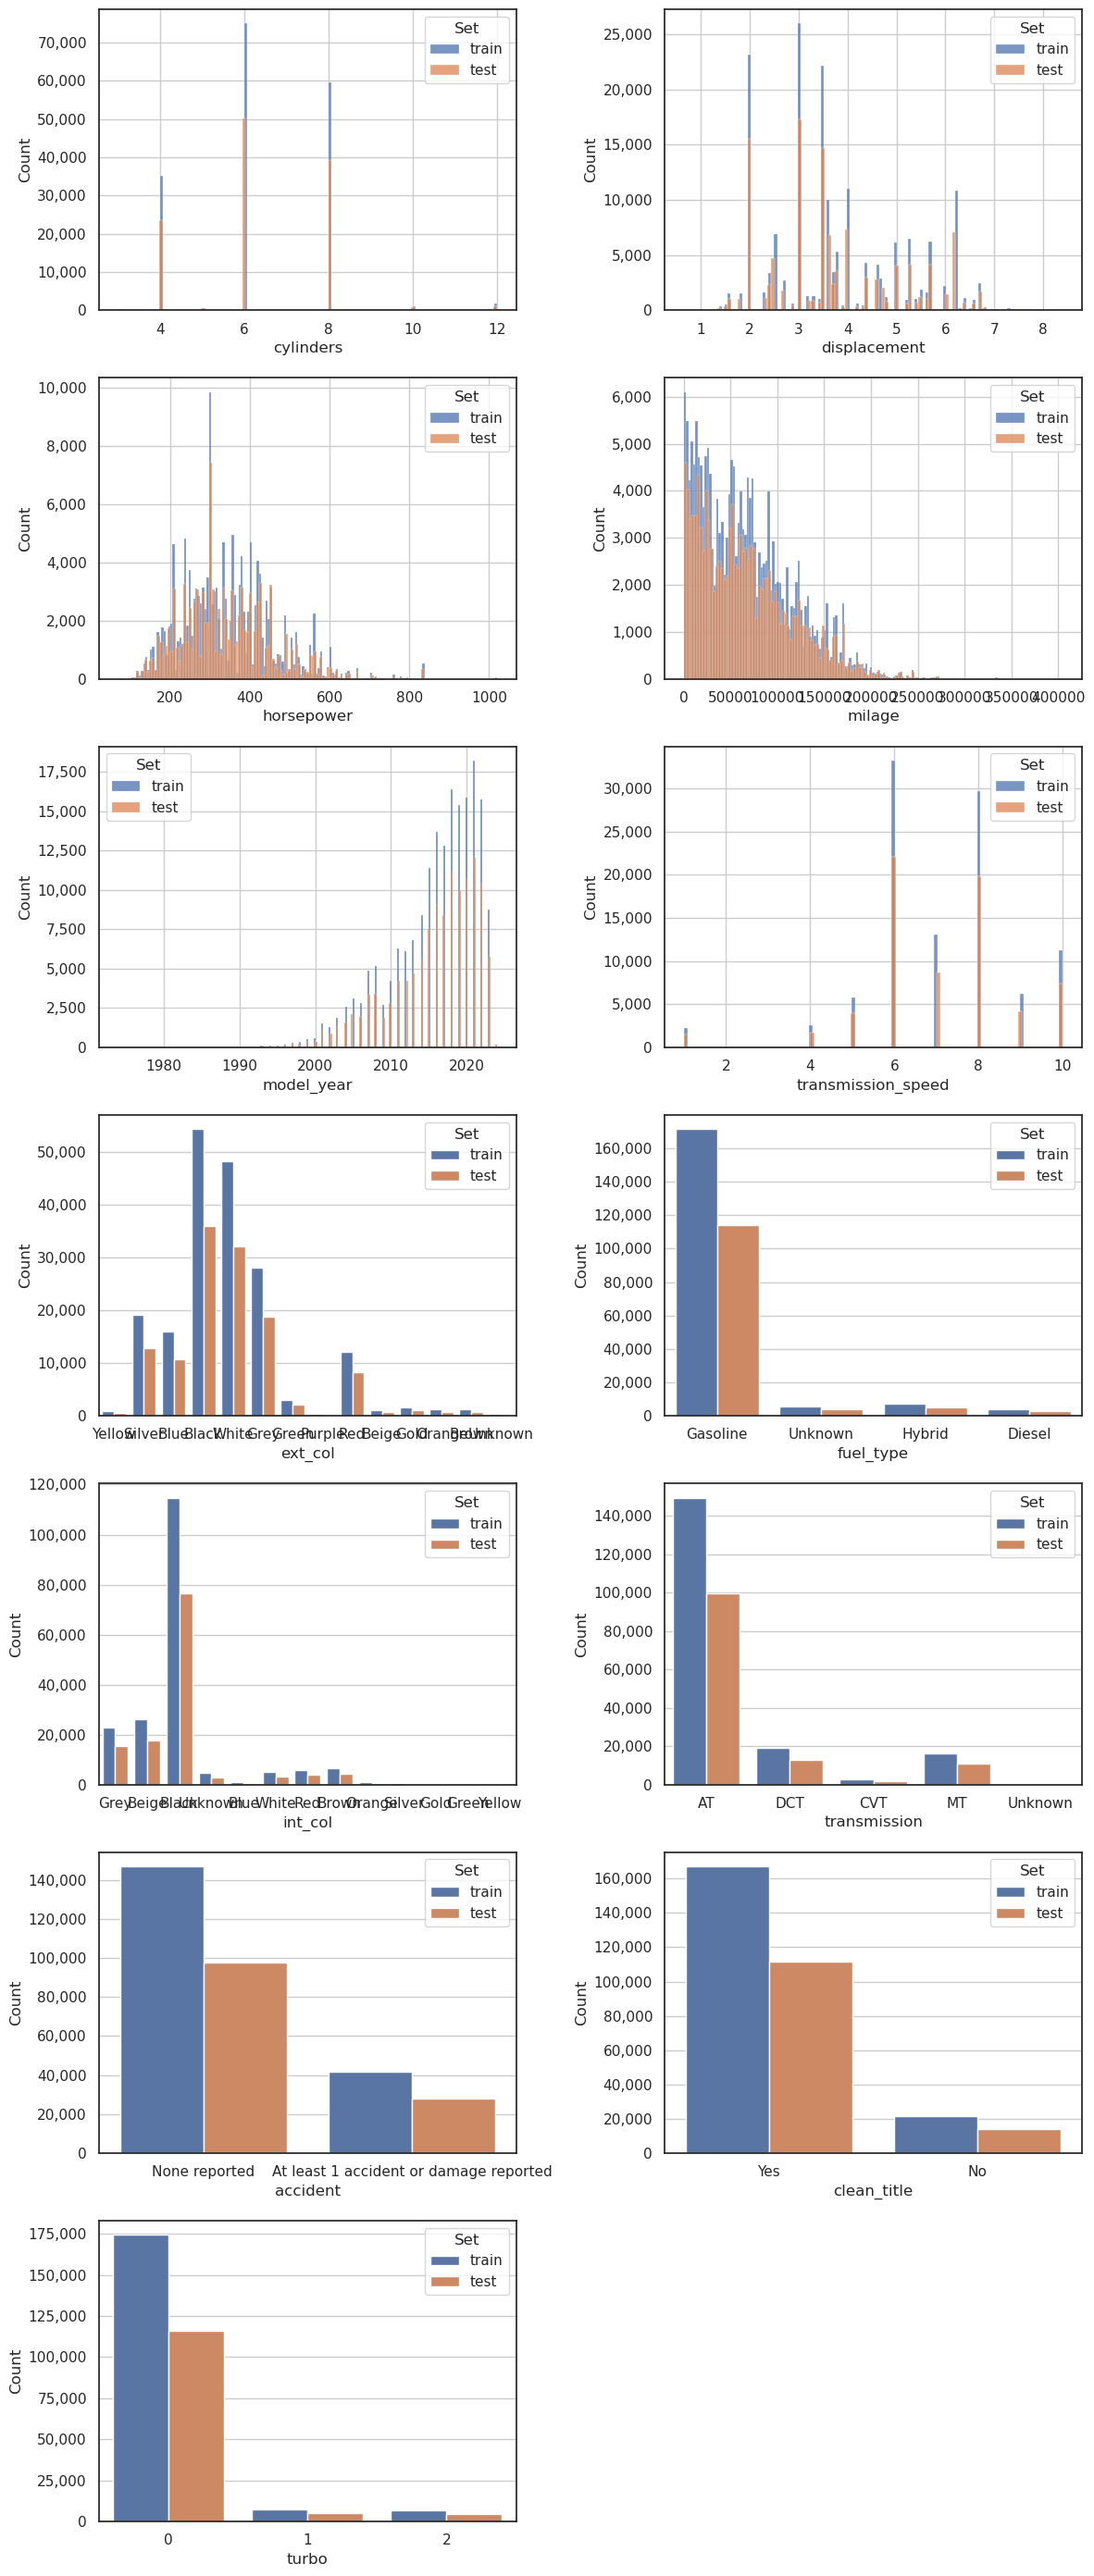

In [12]:
# plot features
unmerged_data = [train_data.assign(Set="train"), test_data.assign(Set="test")]
merged_data = pd.concat(unmerged_data, ignore_index=True, join="inner")
feature_groups = [
    (numerical_features, histplot),
    (nominal_features, countplot),
    (ordinal_features, countplot),
]
fig, axes = subplots(feature_groups, data=merged_data, hue="Set")

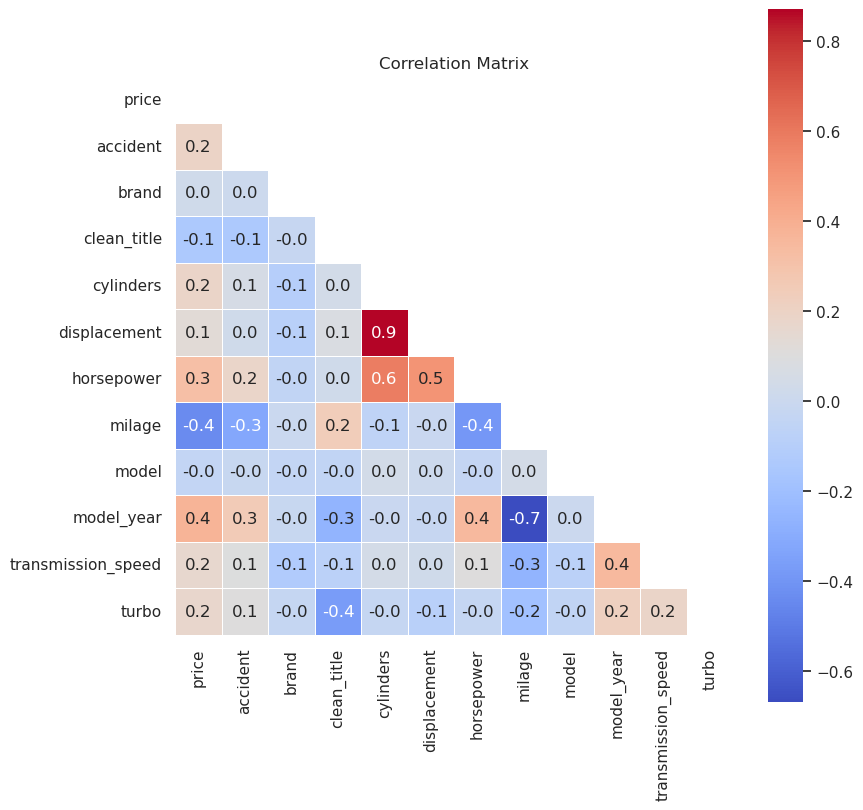

In [13]:
# plot correlations
corr_data = train_data_encoded[corr_features]
corr = corr_data.fillna(corr_data.median()).corr()

ax = heatmap(data=corr, mask=np.triu(corr))
_ = ax.set_title("Correlation Matrix")

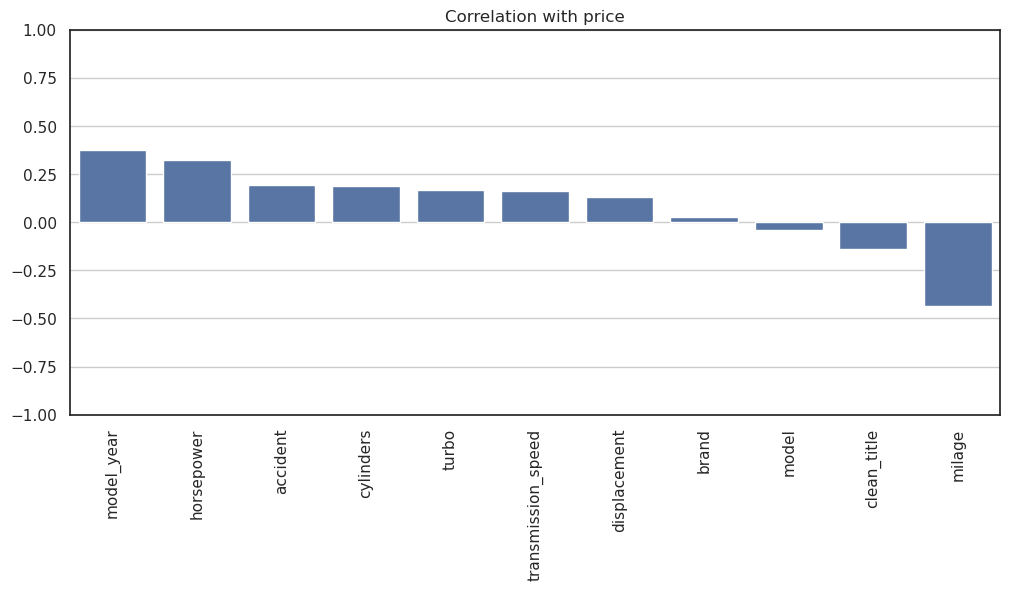

In [14]:
# plot target correlations
corrwith = corr[target].drop(target).sort_values(ascending=False)

ax = barplot(x=corrwith.index, y=corrwith.to_numpy(), rotation=90)
_ = ax.set_xlabel("")
_ = ax.set_ylim(-1, 1)
_ = ax.set_title(f"Correlation with {target}")

In [15]:
# validate that train and test sets have similar distributions
score = adversarial_score(data=merged_data, model=LGBMClassifier(verbose=-1))

threshold = 0.6
comp = "<" if score < threshold else ">="
message = "indistinguishable" if score < threshold else "distinguishable"
print(f"Score = {score:.2f} {comp} threshold = {threshold} → distributions {message}")

Score = 0.50 < threshold = 0.6 → distributions indistinguishable


# Data Preprocessing

In [16]:
# split data into training and test sets
X = train_data[features]
y = train_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# define preprocessing columns and steps
transformer_config = {
    "numerical": {
        "columns": numerical_features,
        "steps": [
            (
                "impute",
                SimpleImputer(strategy="median"),
            ),
            (
                "scale",
                RobustScaler(),
            ),
        ],
    },
    "nominal": {
        "columns": nominal_features,
        "steps": [
            (
                "encode",
                OneHotEncoder(
                    sparse_output=False,
                    handle_unknown="ignore",
                ),
            ),
        ],
    },
    "ordinal": {
        "columns": ordinal_features,
        "steps": [
            (
                "encode",
                OrdinalEncoder(
                    categories=ordinal_categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
            ),
        ],
    },
    "high_cardinality": {
        "columns": high_cardinality_features,
        "steps": [
            (
                "encode",
                TargetEncoder(),
            ),
        ],
    },
}

In [18]:
# build preprocessor
transformers = []
for feature_type, config in transformer_config.items():
    columns = config["columns"]
    steps = config["steps"]
    feature_pipeline = Pipeline(steps=steps)
    transformers.append((feature_type, feature_pipeline, columns))

preprocessor = ColumnTransformer(transformers=transformers)
preprocessor.set_output(transform="pandas")

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature

In [19]:
# define scoring metrics
metrics = {
    "r2": {
        "func": r2_score,
    },
    "neg_mae": {
        "func": lambda y_true, y_pred: -mean_absolute_error(y_true, y_pred),
    },
    "neg_rmse": {
        "func": lambda y_true, y_pred: -root_mean_squared_error(y_true, y_pred),
    },
    "neg_rmsle": {
        "func": lambda y_true, y_pred: (
            -root_mean_squared_log_error(y_true, np.maximum(y_pred, 0))
        ),
    },
}

primary_metric = "neg_rmse"
primary_scorer = make_scorer(metrics[primary_metric]["func"])

# Modelling

In [20]:
# create models and parameter spaces
models = {
    "ridge": {
        "model": Ridge(),
        "params": {
            "ridge__alpha": ("float", 1e-3, 1e3, {"log": True}),
        },
    },
    # too slow
    # "svr": {
    #     "model": SVR(),
    #     "params": {
    #         "svr__C": ("float", 1e-3, 1e3, {"log": True}),
    #         "svr__kernel": ("categorical", ["linear", "rbf", "poly"], None, {}),
    #         "svr__gamma": ("float", 1e-4, 1e0, {"log": True}),
    #         "svr__epsilon": ("float", 1e-3, 1.0, {"log": True}),
    #     },
    # },
    # too slow
    # "rf": {
    #     "model": RandomForestRegressor(random_state=42),
    #     "params": {
    #         "rf__n_estimators": ("int", 50, 500, {}),
    #         "rf__max_depth": ("int", 3, 20, {}),
    #         "rf__min_samples_split": ("int", 2, 20, {}),
    #         "rf__min_samples_leaf": ("int", 1, 10, {}),
    #         "rf__max_features": ("categorical", ["sqrt", "log2"], None, {}),
    #     },
    # },
    # too slow
    # "decision": {
    #     "model": DecisionTreeRegressor(random_state=42),
    #     "params": {
    #         "decision__max_depth": ("int", 3, 20, {}),
    #         "decision__min_samples_split": ("int", 2, 20, {}),
    #         "decision__min_samples_leaf": ("int", 1, 10, {}),
    #         "decision__criterion": (
    #             "categorical",
    #             ["squared_error", "absolute_error"],
    #             None,
    #             {},
    #         ),
    #     },
    # },
    "xgb": {
        "model": XGBRegressor(random_state=42, enable_categorical=True),
        "params": {
            "xgb__n_estimators": ("int", 100, 1000, {}),
            "xgb__max_depth": ("int", 3, 10, {}),
            "xgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "xgb__subsample": ("float", 0.5, 1.0, {}),
            "xgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "xgb__min_child_weight": ("int", 1, 10, {}),
            "xgb__gamma": ("float", 1e-8, 1.0, {"log": True}),
        },
    },
    "lgb": {
        "model": LGBMRegressor(random_state=42, verbose=-1),
        "params": {
            "lgb__n_estimators": ("int", 100, 1000, {}),
            "lgb__num_leaves": ("int", 31, 128, {}),
            "lgb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "lgb__subsample": ("float", 0.5, 1.0, {}),
            "lgb__colsample_bytree": ("float", 0.5, 1.0, {}),
            "lgb__min_child_samples": ("int", 20, 200, {}),
            "lgb__reg_alpha": ("float", 1e-8, 10.0, {"log": True}),
            "lgb__reg_lambda": ("float", 1e-8, 10.0, {"log": True}),
        },
    },
    # too slow
    # "gb": {
    #     "model": GradientBoostingRegressor(random_state=42),
    #     "params": {
    #         "gb__n_estimators": ("int", 50, 500, {}),
    #         "gb__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
    #         "gb__max_depth": ("int", 3, 10, {}),
    #         "gb__subsample": ("float", 0.5, 1.0, {}),
    #         "gb__min_samples_split": ("int", 2, 20, {}),
    #         "gb__min_samples_leaf": ("int", 1, 10, {}),
    #     },
    # },
    # too slow
    # "ada": {
    #     "model": AdaBoostRegressor(random_state=42),
    #     "params": {
    #         "ada__n_estimators": ("int", 50, 500, {}),
    #         "ada__learning_rate": ("float", 1e-3, 1.0, {"log": True}),
    #     },
    # },
    "cat": {
        "model": CatBoostRegressor(
            random_state=42,
            verbose=0,
            bootstrap_type="Bernoulli",
            allow_writing_files=False,
        ),
        "params": {
            "cat__iterations": ("int", 100, 1000, {}),
            "cat__depth": ("int", 3, 10, {}),
            "cat__learning_rate": ("float", 1e-3, 0.3, {"log": True}),
            "cat__l2_leaf_reg": ("float", 1e-3, 10.0, {"log": True}),
            "cat__subsample": ("float", 0.5, 1.0, {}),
        },
    },
}

In [21]:
# train all models with default parameters on X_train
train_results_list = []
train_times = {}
pipelines = {}

cv_train = KFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_config in models.items():
    pipeline = Pipeline(
        [
            ("preprocessor", preprocessor),
            (model_name, model_config["model"]),
        ]
    )

    start_time = time.time()
    search = GridSearchCV(
        estimator=pipeline,
        param_grid={},
        cv=cv_train,
        scoring=primary_scorer,
        refit=True,
    )
    search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    cv_scores = {primary_metric: search.cv_results_["mean_test_score"][0]}
    cv_scores["model"] = model_name

    pipelines[model_name] = search.best_estimator_
    train_times[model_name] = elapsed_time
    train_results_list.append(cv_scores)

train_results = pd.DataFrame(train_results_list).set_index("model")
train_results = train_results.sort_values(primary_metric, ascending=False)
best_model_name = str(train_results[primary_metric].idxmax())
display(train_results)

,neg_rmse
model,
lgb,-39279.016
cat,-39548.083
xgb,-40051.162
ridge,-40433.396


In [22]:
# define objective function for tuning
def make_objective(model_name, cv, metric):
    def objective(trial):
        param_space = models[model_name]["params"]
        params = {}
        for param_name, spec in param_space.items():
            suggest_type, low, high, kwargs = spec
            if suggest_type == "int":
                params[param_name] = trial.suggest_int(param_name, low, high, **kwargs)
            elif suggest_type == "float":
                params[param_name] = trial.suggest_float(
                    param_name, low, high, **kwargs
                )
            elif suggest_type == "categorical":
                params[param_name] = trial.suggest_categorical(param_name, low)

        trial_pipeline = clone(pipelines[model_name])
        trial_pipeline.set_params(**params)

        scores = []
        for train_idx, val_idx in cv.split(X_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            trial_pipeline.fit(X_fold_train, y_fold_train)
            y_fold_pred = trial_pipeline.predict(X_fold_val)
            scores.append(metrics[metric]["func"](y_fold_val, y_fold_pred))

        return sum(scores) / len(scores)

    return objective

In [23]:
# tune best model on X_train
cv_tune = KFold(n_splits=5, shuffle=True, random_state=42)

tuned_start_time = time.time()

study = optuna.create_study(
    direction="maximize", sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(
    make_objective(best_model_name, cv_tune, primary_metric),
    n_trials=5,
    show_progress_bar=True,
)

tuned_elapsed_time = time.time() - tuned_start_time

tuned_model_name = f"{best_model_name}_tuned"
tuned_params = study.best_params

tuned_pipeline = clone(pipelines[best_model_name])
tuned_pipeline.set_params(**tuned_params)
tuned_pipeline.fit(X_train, y_train)

pipelines[tuned_model_name] = tuned_pipeline
train_times[tuned_model_name] = tuned_elapsed_time

tune_results = train_results.loc[[best_model_name]].copy()
tune_results.loc[tuned_model_name] = {primary_metric: study.best_value}
tune_results = tune_results.sort_values(primary_metric, ascending=False)
display(tune_results)
display(tuned_params)

Best trial: 2. Best value: -39133.2: 100%|██████████| 5/5 [1:37:28<00:00, 1169.63s/it]  


,neg_rmse
model,
lgb_tuned,-39133.208
lgb,-39279.016


{'lgb__n_estimators': 374,
 'lgb__num_leaves': 82,
 'lgb__learning_rate': 0.01174843954800703,
 'lgb__subsample': 0.645614570099021,
 'lgb__colsample_bytree': 0.8059264473611898,
 'lgb__min_child_samples': 45,
 'lgb__reg_alpha': 4.258943089524393e-06,
 'lgb__reg_lambda': 1.9826980964985924e-05}

In [24]:
# evaluate all models on X_test
test_results_list = []

for model_name, pipeline in pipelines.items():
    y_test_pred = pipeline.predict(X_test)

    test_scores = {}
    for metric_name, metric_config in metrics.items():
        test_scores[metric_name] = metric_config["func"](y_test, y_test_pred)

    test_scores["model"] = model_name
    test_results_list.append(test_scores)

test_results = pd.DataFrame(test_results_list).set_index("model")
test_results["train_time"] = pd.Series(train_times)
test_results = test_results.sort_values(primary_metric, ascending=False)

display(test_results)

,r2,neg_mae,neg_rmse,neg_rmsle,train_time
model,,,,,
lgb_tuned,0.352,-17220.706,-39583.810,-0.526,5848.154
lgb,0.351,-17336.358,-39611.211,-0.525,367.904
cat,0.344,-17501.411,-39839.997,-0.528,1542.500
xgb,0.331,-17674.818,-40216.352,-0.538,480.095
ridge,0.305,-19263.942,-41003.773,-1.783,246.010


In [25]:
# retrain tuned model on X_train and X_test
final_model = clone(tuned_pipeline)
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('lgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('nominal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

# Results

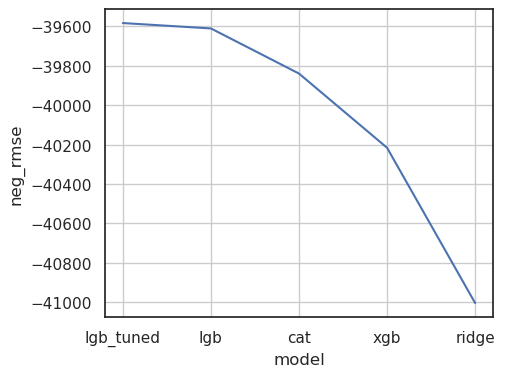

In [26]:
# plot initial results
ax = lineplot(data=test_results.reset_index(), x="model", y=primary_metric)

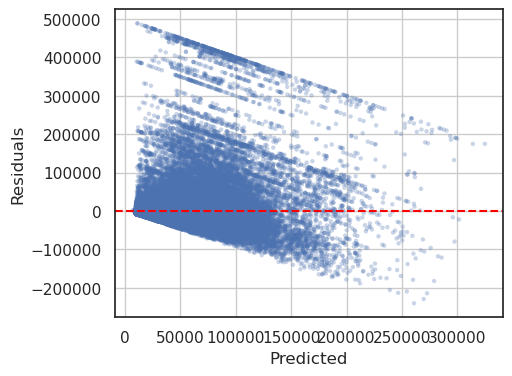

In [27]:
# plot residuals
y_pred = final_model.predict(X)
residuals = y.values - y_pred

ax = scatterplot(x=y_pred, y=residuals, alpha=0.3, s=10, edgecolor="none")
_ = ax.axhline(0, color="red", linestyle="--")
_ = ax.set_xlabel("Predicted")
_ = ax.set_ylabel("Residuals")

In [28]:
# make predictions
test_pred = final_model.predict(test_data)

# write to submissions file
sub_data[target] = test_pred
sub_data.to_csv("submission.csv", index=True, index_label=index_col)

pd.read_csv("submission.csv")

,id,price
0,188533,18783.065
1,188534,82114.474
2,188535,54671.923
3,188536,27975.673
4,188537,30460.391
...,...,...
125685,314218,25157.408
125686,314219,54552.672
125687,314220,24514.106
125688,314221,17729.242


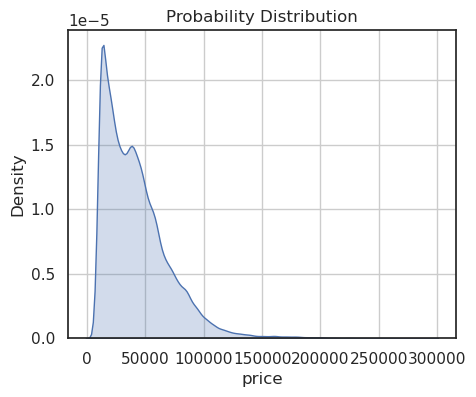

In [29]:
# plot predictions/probabilities
ax = kdeplot(x=sub_data[target])
_ = ax.set_title("Probability Distribution")